In [1]:
import pandas as pd

df_car_fuel = pd.read_csv('car_fuel_efficiency_2026.csv')
df_car_fuel.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Preparing the dataset

In [11]:
# reduce the dataframe to the subset of columns that will be used:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df_car_fuel_base = df_car_fuel[base]
df_car_fuel_base.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [21]:
import numpy as np

def prepare_data_sets(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

## EDA of fuel_efficiency_mpg

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

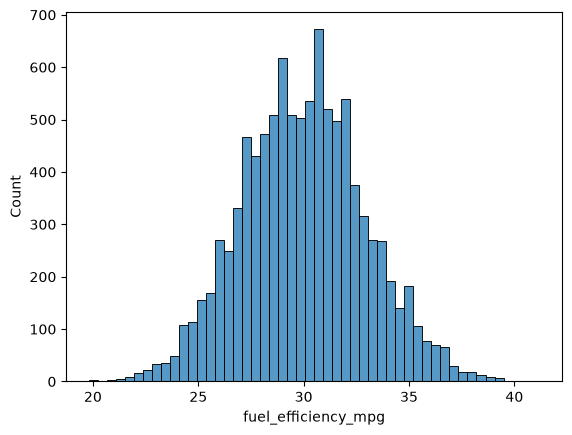

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#The %matplotlib inline line makes sure the plots are displayed in the notebook
%matplotlib inline
sns.histplot(df_car_fuel_base.fuel_efficiency_mpg, bins=50)

# Question 1: Missing values

In [13]:
df_car_fuel_base.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Question 2: Median for horsepower

In [14]:
df_car_fuel_base.horsepower.median()

np.float64(254.0)

# Question 3: Filling NAs

## Preparing datasets

In [15]:
df_train, df_val, df_test = prepare_data_sets(df_car_fuel_base, 42)
#
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Training using data that filled NA with zeros

In [18]:
X_train_filled_0 = df_train.fillna(0).values

w0_filled_0, w_filled_0 = train_linear_regression(X_train_filled_0, y_train)
w0_filled_0, w_filled_0


(np.float64(-153.8849618823138),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

## Training using data that filled NA with median

In [25]:
X_train_median = df_train.horsepower.median()
X_train_filled_median = df_train.fillna(X_train_median).values

w0_filled_median, w_filled_median = train_linear_regression(X_train_filled_median, y_train)
w0_filled_median, w_filled_median

(np.float64(-153.34000048862066),
 array([-0.00102491, -0.00647299, -0.00388832,  0.10200021]))

## Comparing using a graph

<Axes: ylabel='Count'>

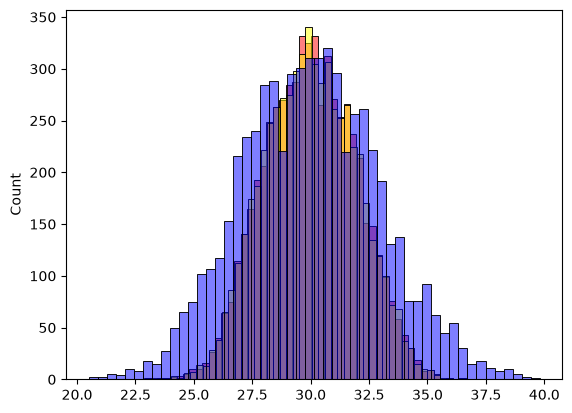

In [27]:
y_pred_filled_0 = w0_filled_0 + X_train_filled_0.dot(w_filled_0)
y_pred_filled_median = w0_filled_median + X_train_filled_median.dot(w_filled_median)

sns.histplot(y_pred_filled_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_pred_filled_median, color='yellow', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## Comparing using RMSE

In [29]:
RMSE_pred_filled_0  = rmse(y_train, y_pred_filled_0)
round(RMSE_pred_filled_0, 3)

np.float64(2.2)

In [30]:
RMSE_pred_filled_median = rmse(y_train, y_pred_filled_median)
round(RMSE_pred_filled_median, 3)

np.float64(2.198)